# Block 6 — Deep Learning with Time Series Data: Modern Architectures

**Goals for this block:**
- Understand differences between LSTM, GRU and TCN.
- Connect receptive field (TCN) and context window (Transformer/RNN) to the sliding-window setup.
- Run a forecasting with TCN and (optional: Transformer).

## 0. Setup & Environment

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
tf.config.set_logical_device_configuration(gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=6500)])

import torch
assert torch.cuda.is_available()
torch.cuda.set_per_process_memory_fraction(0.3)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

from darts.dataprocessing.transformers import Scaler
from darts.utils.missing_values import fill_missing_values
from darts import TimeSeries


## Loading Elctricity Consumption Dataset

Electricity Consumption of **households & SMEs (low voltage)** and **businesses & services (medium voltage)** in the city of Zurich, with values recorded every **15 minutes**.

The electricity consumption is combined with weather measurements recorded by **three different stations in the city of Zurich** with a hourly frequency . 

Both dataset sources are updated continuously, but this dataset only retrains values between **2015-01-01** and **2022-08-31**. The time index was converted from CET time zone to UTC.

Components Descriptions:

`Value_NE5` : Households & SMEs electricity consumption (low voltage, grid level 7) in kWh

`Value_NE7` : Business and services electricity consumption (medium voltage, grid level 5) in kWh

`Hr [%Hr]` : Relative humidity

`RainDur [min]` : Duration of precipitation (divided by 4 for conversion from hourly to quarter-hourly records)

`T [°C]` : Temperature

`WD [°]` : Wind direction

`WVv [m/s]` : Wind vector speed

`p [hPa]` : Air pressure

`WVs [m/s]` : Wind scalar speed

`StrGlo [W/m2]` : Global solar irradiation

In [2]:
from darts.datasets import ElectricityConsumptionZurichDataset

series = ElectricityConsumptionZurichDataset().load() 
target_columns = ["Value_NE5", "Value_NE7"]
covariate_columns = ['Hr [%Hr]', 'RainDur [min]', 'StrGlo [W/m2]', 'T [°C]', 'WD [°]', 'WVs [m/s]', 'WVv [m/s]', 'p [hPa]']

In [3]:
series.to_dataframe().head()

,Value_NE5,Value_NE7,Hr [%Hr],RainDur [min],StrGlo [W/m2],T [°C],WD [°],WVs [m/s],WVv [m/s],p [hPa]
Timestamp,,,,,,,,,,
2015-01-01 00:00:00,21975.938,44062.418,90.47,0.0,0.01,-2.48,353.85,0.61,0.60,982.64
2015-01-01 00:15:00,22197.983,43462.382,90.22,0.0,0.01,-2.48,270.76,0.78,0.78,982.73
2015-01-01 00:30:00,22449.448,43002.521,89.96,0.0,0.02,-2.47,187.67,0.96,0.96,982.82
2015-01-01 00:45:00,22124.219,42215.430,89.70,0.0,0.02,-2.46,104.57,1.14,1.13,982.91
2015-01-01 01:00:00,21963.707,41937.865,89.45,0.0,0.02,-2.46,21.48,1.31,1.31,983.00


Text(0, 0.5, 'Covariate Values')

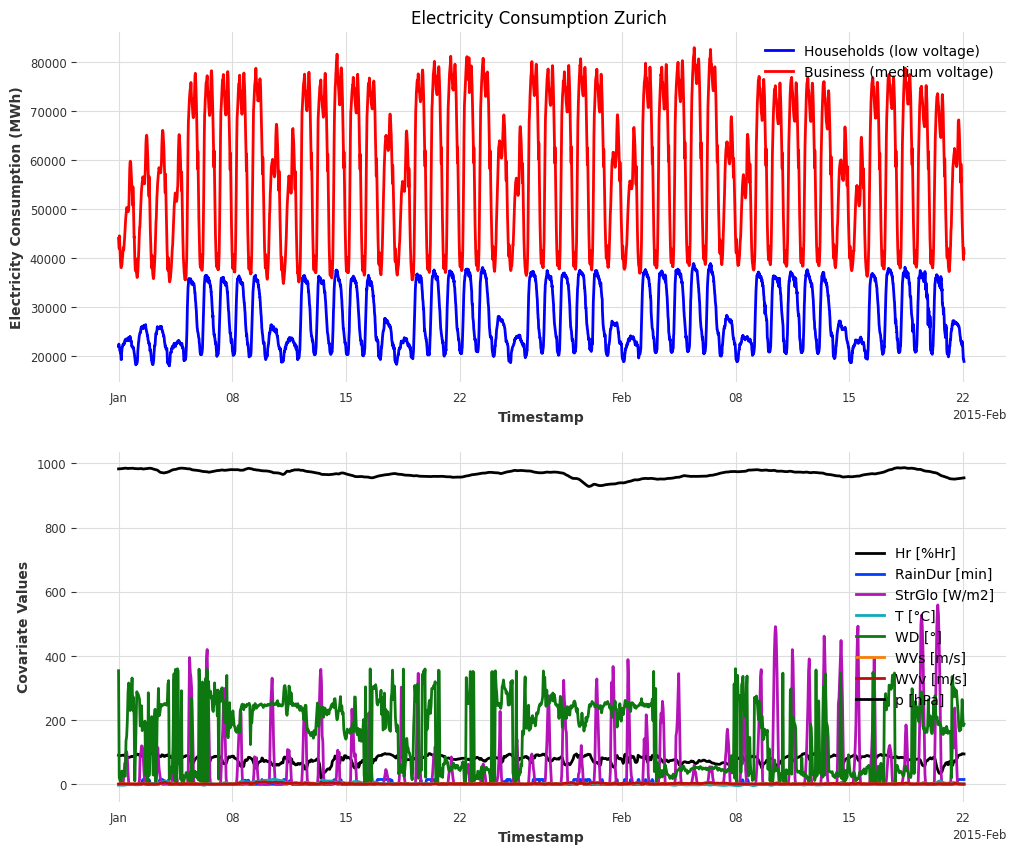

In [4]:
# Plot actual values on first subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
series["Value_NE5"][:5000].plot(label ="Households (low voltage)", color='blue', ax=ax1)
series["Value_NE7"][:5000].plot(label="Business (medium voltage)", color='red', title= "Electricity Consumption Zurich ", ax=ax1)
ax1.set_ylabel("Electricity Consumption (MWh)")
series[covariate_columns][:5000].plot( ax=ax2)
ax2.set_ylabel("Covariate Values")

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Preprocess the target and covariate time-series</h2>

1. split the time series into two different series
   `target_series`and `past_covariates`
2. preprocess the target_series
   - resample the data from `sampling_rate of 15min` to `hourly`
   - split the data to 70% train and 30% test
   - scale the data using the StandardScaler
2. preprocess the past_covariates series using the exact same parameters

This exercise will help you understand how to deal with covariates.
</div>

In [5]:
# splt the time series into target and covariates
target_series = series[target_columns]
past_covariates = series[covariate_columns]

In [ ]:
# preprocess target series
target_series_resampled = target_series.resample('H', method='sum')

train_target, test_target = target_series_resampled.split_before(0.7)

scaler_target = Scaler(StandardScaler())
train_scaled = scaler_target.fit_transform(train_target)
test_scaled = scaler_target.transform(test_target)

# preprocess covariate series
past_covariates_resampled = past_covariates.resample('H', method='mean')

train_cov, test_cov = past_covariates_resampled.split_before(0.7)

scaler_cov = Scaler(StandardScaler())
train_cov_scaled = scaler_cov.fit_transform(train_cov)
test_cov_scaled = scaler_cov.transform(test_cov)
                                                                                                    

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/Bitkom 11.2025/time-series-lab/.venv/lib/python3.13/site-packages/xarray/groupers.py:530: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/Bitkom 11.2025/time-series-lab/.venv/lib/python3.13/site-packages/xarray/groupers.py:530: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Correlation "target series" <=> "covariate series"</h2>


1. Use the plot_ccf to generate the cross correlation between the target and covariate series

   **Remark**: we can only analyze univariate series. Select ONE-by-ONE a target series and a covariate

2. plot the first 100 values of the selected time-series (Use the rescaled data)

This exercise will help you analyze the importance of the covariates.
</div>

target columns: 'Value_NE5', 'Value_NE7'

covariate_columns = 'Hr [%Hr]', 'RainDur [min]', 'StrGlo [W/m2]', 'T [°C]', 'WD [°]', 'WVs [m/s]', 'WVv [m/s]', 'p [hPa]'

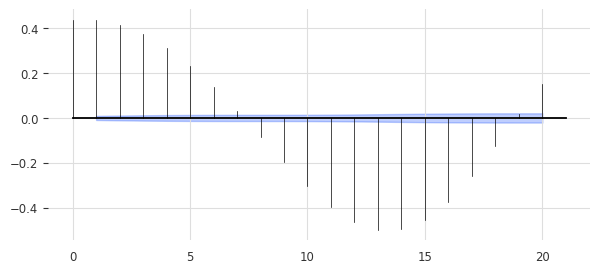

In [21]:
# plot cross-correlation function between target and covariate (keep max_lag=10 for performance reasons)
from darts.utils.statistics import plot_ccf

tr_column = 'Value_NE5'
cov_column = 'StrGlo [W/m2]'

plot_ccf(train_scaled[tr_column], train_cov_scaled[cov_column], max_lag=20, fig_size=(7, 3))


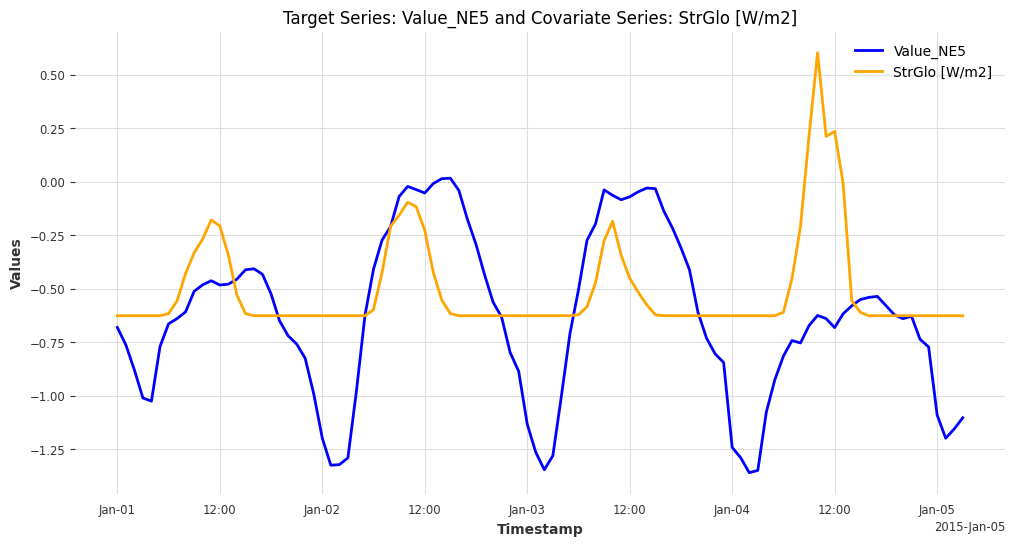

In [22]:
# plot the selected target and covariate series (Use the rescaled data train_scaled and train_cov_scaled)
fig, ax = plt.subplots(figsize=(12, 6))
train_scaled[tr_column][:100].plot(label=tr_column, color='blue', ax=ax)
train_cov_scaled[cov_column][:100].plot(label=cov_column, color='orange', ax=ax)
ax.set_title(f'Target Series: {tr_column} and Covariate Series: {cov_column}')
ax.set_ylabel('Values')
ax.legend()

# Adding future covariates to the data

Future covariates are known or predictable covariates into the future (e.g., holidays, planned events)


In [ ]:
# adding future covariates to the data
from darts.utils.timeseries_generation import datetime_attribute_timeseries


preprocessed_series = train_scaled.append(test_scaled)

hour_series  = datetime_attribute_timeseries(preprocessed_series, attribute="hour", one_hot=False, cyclic=True)
dow_series   = datetime_attribute_timeseries(preprocessed_series, attribute="day_of_week", one_hot=True)
month_series = datetime_attribute_timeseries(preprocessed_series, attribute="month", one_hot=True)
future_covs  = hour_series.stack(dow_series).stack(month_series)

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train an RNN model with and without covariates</h2>

1. Train an **RNN model** only on target series

2. Train an **RNN model** with the past and future covariate series
    Use both **past covariates** (weather data) and **future covariates** (time features)

3. Evaluate and compare the models using MAE, RMSE, MAPE and sMAPE metrics

6. Visualize the predictions vs actual values

</div>


In [ ]:
from darts.models import BlockRNNModel

#### RNN model using only target series

In [ ]:
# build a model where window size is 3 days and forecast horizon is 1 day

window_size = 24*3  # 3 days
forecast_horizon = 24  # one day
batch_size = 256
hidden_size = 64
n_rnn_layers = 2

model_simple = BlockRNNModel(model="RNN",
                input_chunk_length=window_size,
                hidden_dim=hidden_size, 
                n_rnn_layers=n_rnn_layers,
                batch_size=batch_size,
                output_chunk_length=forecast_horizon,
                random_state=42,
                pl_trainer_kwargs={"accelerator": "gpu"})

HINT: To calculate the training time use `time.time()` to get the python time.

In [ ]:
# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()

model_simple.fit(
    series=train_scaled,           
    epochs=2,
    verbose=True)

end_time = time.time()
training_time_rnn_simple = end_time - start_time

In [ ]:
# Make predictions on the test set (use the historical_forecasts method)
 
pred_series_rnn_simple = model_simple.historical_forecasts(series=test_scaled,
                                            forecast_horizon=forecast_horizon, 
                                            retrain=False, 
                                            last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_rnn_simple_unscaled = scaler_target.inverse_transform(pred_series_rnn_simple)

In [ ]:
from darts.metrics import mae, rmse, mape, smape
# calculate evaluation metrics

evaluation_metrics_simple_rnn = {
    "MAE": mae(pred_series_rnn_simple_unscaled, test_target),
    "RMSE": rmse(pred_series_rnn_simple_unscaled, test_target),
    "MAPE": mape(pred_series_rnn_simple_unscaled, test_target),
    "sMAPE": smape(pred_series_rnn_simple_unscaled, test_target),
}

#### RNN model using past and future covariates

In [ ]:
# keep the same parameters as the simple RNN 
model_cov = BlockRNNModel(model="RNN",
                input_chunk_length=window_size,
                hidden_dim=hidden_size, 
                n_rnn_layers=n_rnn_layers,
                batch_size=batch_size,
                output_chunk_length=forecast_horizon,
                random_state=42,
                pl_trainer_kwargs={"accelerator": "gpu"})

In [ ]:
# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()

model_cov.fit(
    series=train_scaled,         
    past_covariates=train_cov_scaled,
    future_covariates=future_covs, 
    epochs=2,
    verbose=True)

end_time = time.time()
training_time_rnn_cov = end_time - start_time

In [ ]:
# Make predictions on the test set (use the historical_forecasts method)

pred_series_rnn_cov = model_cov.historical_forecasts(series=test_scaled,
                                                    past_covariates=test_cov_scaled,
                                                    future_covariates=future_covs,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_rnn_cov_unscaled = scaler_target.inverse_transform(pred_series_rnn_cov)

In [ ]:
# calculate evaluation metrics

evaluation_metrics_cov_rnn = {
    "MAE": mae(pred_series_rnn_cov_unscaled, test_target),
    "RMSE": rmse(pred_series_rnn_cov_unscaled, test_target),
    "MAPE": mape(pred_series_rnn_cov_unscaled, test_target),
    "sMAPE": smape(pred_series_rnn_cov_unscaled, test_target),
}

In [ ]:
print("RNN with past and future covariates:", evaluation_metrics_cov_rnn)
print("\n")
print("Training time RNN with covariates (seconds):", training_time_rnn_cov)
print("\n")
print("################################")
print("\n") 
print("RNN without covariates:", evaluation_metrics_simple_rnn)
print("\n")
print("Training time RNN without covariates (seconds):", training_time_rnn_simple)

In [ ]:
# Plotting some predictions vs actuals
start_idx = pd.Timestamp('2021-07-25 03:00:00')
end_idx = pd.Timestamp('2021-08-02 03:00:00')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
test_target[target_columns[0]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax1)
pred_series_rnn_cov_unscaled[target_columns[0]][start_idx:end_idx].plot(label="Forecast Cov RNN", color='green', ax=ax1)
pred_series_rnn_simple_unscaled[target_columns[0]][start_idx:end_idx].plot(label="Forecast Simple RNN", color='red', title=f"Actual vs Predicted Energy Consumption {target_columns[0]}", ax=ax1)

test_target[target_columns[1]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax2)
pred_series_rnn_cov_unscaled[target_columns[1]][start_idx:end_idx].plot(label="Forecast Cov RNN", color='green', ax=ax2)
pred_series_rnn_simple_unscaled[target_columns[1]][start_idx:end_idx].plot(label="Forecast Simple RNN", color='red', title=f"Actual vs Predicted Energy Consumption {target_columns[1]}", ax=ax2)

ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()

Now we will explore the implementation of modern deep learning architectures for time series forecasting using the Darts library. In this section, we'll compare three powerful approaches:

### **Variants of Recurrent Neural Networks (RNN)**
- **GRU (Gated Recurrent Unit)**: A simplified LSTM variant that captures temporal dependencies
- **LSTM (Long Short-Term Memory)**: Classic architecture for sequential data with memory cells

### **Temporal Convolutional Networks (TCN)**
- **Key advantage**: Parallelizable training (unlike RNNs)
- **Receptive field**: Controlled by kernel size and dilation patterns
- **Best for**: Local patterns and seasonal dependencies

### **Transformer Models**
- **Attention mechanism**: Captures long-range dependencies efficiently
- **Context window**: Direct access to entire input sequence
- **Best for**: Complex temporal relationships and non-local patterns

Let's implement and compare these architectures:

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train a LSTM, GRU, TCN models</h2>

1. Train an **LSTM model** using the preprocessed electricity consumption data

(Use both **past covariates** (weather data) and **future covariates** (time features))

2. Train a **GRU model** with the same parameters for comparison

(Use both **past covariates** (weather data) and **future covariates** (time features))

3. Train a **TCN model** and compare performance

(Use **past covariates** (weather data). Attention: TCN does not handle future covariates)

4. Evaluate and compare the models using sMAPE metrics

5. Visualize the predictions vs actual values

</div>


### RNN model

In [ ]:
window_size = 24*3  # 3 days
forecast_horizon = 24  # one day
batch_size = 256
hidden_size = 64
n_rnn_layers = 2

In [ ]:
# get the results variable from the last RNN model with covariates
model_rnn = model_cov
pred_series_rnn_unscaled = pred_series_rnn_cov_unscaled
evaluation_metrics_rnn = evaluation_metrics_cov_rnn
training_time_rnn = training_time_rnn_cov

### LTSM model

In [ ]:
# LSTM model
model_lstm = BlockRNNModel(
        model="LSTM",
        input_chunk_length=window_size,
        hidden_dim=hidden_size, 
        n_rnn_layers=n_rnn_layers,
        batch_size=batch_size,
        output_chunk_length=forecast_horizon,
        random_state=42,
        pl_trainer_kwargs={"accelerator": "gpu"})

# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()
model_lstm.fit(
    series=train_scaled,         
    past_covariates=train_cov_scaled,
    future_covariates=future_covs, 
    val_future_covariates=future_covs,       
    epochs=2,
    verbose=True)
end_time = time.time()
training_time_lstm = end_time - start_time

# Make predictions on the test set (use the historical_forecasts method)
pred_series_lstm = model_lstm.historical_forecasts(series=test_scaled,
                                                    past_covariates=test_cov_scaled,
                                                    future_covariates=future_covs,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_lstm_unscaled = scaler_target.inverse_transform(pred_series_lstm)

# calculate evaluation metrics
evaluation_metrics_lstm = {
    "MAE": mae(pred_series_lstm_unscaled, test_target),
    "RMSE": rmse(pred_series_lstm_unscaled, test_target),
    "MAPE": mape(pred_series_lstm_unscaled, test_target),
    "sMAPE": smape(pred_series_lstm_unscaled, test_target),
}

### GRU

In [ ]:
# GRU model
model_gru = BlockRNNModel(
        model="GRU",
        input_chunk_length=window_size,
        hidden_dim=hidden_size, 
        n_rnn_layers=n_rnn_layers,
        batch_size=batch_size,
        output_chunk_length=forecast_horizon,
        random_state=42,
        pl_trainer_kwargs={"accelerator": "gpu"})

# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()
model_gru.fit(
    series=train_scaled,         
    past_covariates=train_cov_scaled,
    future_covariates=future_covs, 
    val_future_covariates=future_covs,       
    epochs=2,
    verbose=True)
end_time = time.time()
training_time_gru= end_time - start_time

# Make predictions on the test set (use the historical_forecasts method)
pred_series_gru = model_gru.historical_forecasts(series=test_scaled,
                                                    past_covariates=test_cov_scaled,
                                                    future_covariates=future_covs,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_gru_unscaled = scaler_target.inverse_transform(pred_series_gru)

# calculate evaluation metrics
evaluation_metrics_gru = {
    "MAE": mae(pred_series_gru_unscaled, test_target),
    "RMSE": rmse(pred_series_gru_unscaled, test_target),
    "MAPE": mape(pred_series_gru_unscaled, test_target),
    "sMAPE": smape(pred_series_gru_unscaled, test_target),
}

### TCN

#### TCN Model Architecture:

- Temporal Convolutional Network with dilated causal convolutions

- Parallelizable training (unlike RNNs)

- Receptive field controlled by kernel size and dilation patterns

- Residual connections and dropout for regularization

**Example Implementation:**

```python
from darts.models import TCNModel

model_tcn = TCNModel(
    input_chunk_length=window_size,     # 168 timesteps lookback (1 week)
    output_chunk_length=forecast_horizon, # 24 timesteps forecast (1 day)
    kernel_size=5,                      # Convolutional kernel size
    num_filters=64,                     # Number of filters per layer
    num_layers=3,                       # Number of TCN layers
    dilation_base=2,                    # Exponential dilation factor
    batch_size=256,                     # Batch size for training
    pl_trainer_kwargs={"accelerator": "gpu"},
    random_state=42,
)
```
**What’s happening**:
kernel_size=5: Size of the 1D convolutional kernel. Controls local pattern detection.

💡 Larger kernels capture longer local dependencies but increase parameters.

num_filters=64: Number of convolutional filters per layer (width of the network).

💡 More filters → more capacity to learn diverse temporal patterns.

num_layers=3: Depth of the TCN (number of dilated conv blocks stacked).

💡 More layers increase the receptive field exponentially with dilations.

dilation_base=2: Exponential growth factor for dilations (1, 2, 4, 8, ...).

💡 Higher base → faster growth of receptive field but potential gaps in coverage.

In [ ]:
from darts.models import TCNModel  

In [ ]:

# TCN model
model_tcn = TCNModel(input_chunk_length=window_size,
                output_chunk_length=forecast_horizon,
                kernel_size=5,
                num_filters=5,
                num_layers=3,
                dilation_base=2,
                batch_size=256,
                pl_trainer_kwargs={"accelerator": "gpu"},
                random_state=42,
                )

# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()
model_tcn.fit(
    series=train_scaled,         
    past_covariates=train_cov_scaled,
    epochs=2,
    verbose=True)
end_time = time.time()
training_time_tcn = end_time - start_time

# Make predictions on the test set (use the historical_forecasts method)
pred_series_tcn = model_tcn.historical_forecasts(series=test_scaled,
                                                    past_covariates=test_cov_scaled,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_tcn_unscaled = scaler_target.inverse_transform(pred_series_tcn)

# calculate evaluation metrics
evaluation_metrics_tcn = {
    "MAE": mae(pred_series_tcn_unscaled, test_target),
    "RMSE": rmse(pred_series_tcn_unscaled, test_target),
    "MAPE": mape(pred_series_tcn_unscaled, test_target),
    "sMAPE": smape(pred_series_tcn_unscaled, test_target),
}

In [ ]:
print("RNN:", evaluation_metrics_rnn)
print("Training time RNN(seconds):", training_time_rnn)
print("\n")
print("################################")
print("\n") 
print("LSTM:", evaluation_metrics_lstm)
print("Training time LSTM (seconds):", training_time_lstm)
print("\n")
print("################################")
print("\n") 
print("GRU:", evaluation_metrics_gru)
print("Training time GRU (seconds):", training_time_gru)
print("\n")
print("################################")
print("\n") 
print("TCN:", evaluation_metrics_tcn)
print("Training time TCN (seconds):", training_time_tcn)    

In [ ]:
# plotting some predictions vs actuals
start_idx = pd.Timestamp('2021-07-25 03:00:00')
end_idx = pd.Timestamp('2021-08-02 03:00:00')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
test_target[target_columns[0]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax1)
pred_series_rnn_unscaled[target_columns[0]][start_idx:end_idx].plot(label=" RNN", color='green', ax=ax1, alpha=0.7)
pred_series_lstm_unscaled[target_columns[0]][start_idx:end_idx].plot(label=" LSTM", color='red', ax=ax1, alpha=0.7)
pred_series_gru_unscaled[target_columns[0]][start_idx:end_idx].plot(label=" GRU", color='orange', ax=ax1, alpha=0.7)
pred_series_tcn_unscaled[target_columns[0]][start_idx:end_idx].plot(label=" TCN", color='purple', alpha=0.7, title=f"Actual vs Predicted Energy Consumption {target_columns[0]}", ax=ax1)

test_target[target_columns[1]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax2)
pred_series_rnn_unscaled[target_columns[1]][start_idx:end_idx].plot(label=" RNN", color='green', ax=ax2, alpha=0.7)
pred_series_lstm_unscaled[target_columns[1]][start_idx:end_idx].plot(label=" LSTM", color='red', ax=ax2, alpha=0.7)
pred_series_gru_unscaled[target_columns[1]][start_idx:end_idx].plot(label=" GRU", color='orange', ax=ax2, alpha=0.7)
pred_series_tcn_unscaled[target_columns[1]][start_idx:end_idx].plot(label=" TCN", color='purple', alpha=0.7, title=f"Actual vs Predicted Energy Consumption {target_columns[1]}", ax=ax2)


<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise (Optional): Train Transformer with DARTS</h2>

In this optional exercise, you'll explore additional forecasting approaches to complete your comparison:

### **Transformer Model**
1. Train a **Transformer model** using past covariates (weather data) (Attention: future covariates not supported)
2. Configure the attention mechanism with appropriate parameters:
   - `d_model`: Embedding dimension (64)
   - `nhead`: Number of attention heads (4) 
   - `num_encoder_layers` and `num_decoder_layers`: Network depth (2 each)

### **Evaluation & Comparison**
5. Compare all models using the same metrics (MAE, RMSE, MAPE, sMAPE)
6. Analyze training times and performance trade-offs
7. Visualize predictions to understand each model's behavior

**Learning Goals:**
- Compare attention mechanisms (Transformer) vs. convolutions (TCN) vs. recurrence (RNN/LSTM/GRU)
- Learn about multivariate forecasting strategies with univariate models

</div>

In [ ]:
from darts.models import TransformerModel

In [ ]:
# Transformer model
model_transformer = TransformerModel(input_chunk_length=window_size,
                        output_chunk_length=forecast_horizon,
                        d_model=64, 
                        nhead=4, 
                        num_encoder_layers=2, 
                        num_decoder_layers=2,
                        dim_feedforward=128,
                        batch_size=256,
                        pl_trainer_kwargs={"accelerator": "gpu"},)

# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()
model_transformer.fit(
    series=train_scaled,         
    past_covariates=train_cov_scaled,
    epochs=2,
    verbose=True)
end_time = time.time()
training_time_transformer = end_time - start_time

# Make predictions on the test set (use the historical_forecasts method)
pred_series_transformer = model_transformer.historical_forecasts(series=test_scaled,
                                                    forecast_horizon=forecast_horizon, 
                                                    past_covariates=test_cov_scaled,
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_transformer_unscaled = scaler_target.inverse_transform(pred_series_transformer)

# calculate evaluation metrics
evaluation_metrics_transformer = {
    "MAE": mae(pred_series_transformer_unscaled, test_target),
    "RMSE": rmse(pred_series_transformer_unscaled, test_target),
    "MAPE": mape(pred_series_transformer_unscaled, test_target),
    "sMAPE": smape(pred_series_transformer_unscaled, test_target
    ),
}

In [ ]:
# Print comprehensive comparison of all models
print("=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)

models_results = {
    "RNN": (evaluation_metrics_rnn, training_time_rnn),
    "LSTM": (evaluation_metrics_lstm, training_time_lstm),
    "GRU": (evaluation_metrics_gru, training_time_gru),
    "TCN": (evaluation_metrics_tcn, training_time_tcn),
    "Transformer": (evaluation_metrics_transformer, training_time_transformer),
}

for model_name, (metrics, train_time) in models_results.items():
    print(f"\n{model_name}:")
    print(f"  sMAPE: {metrics['sMAPE']:.4f}")
    print(f"  MAE:   {metrics['MAE']:.4f}")
    print(f"  RMSE:  {metrics['RMSE']:.4f}")
    print(f"  Training Time: {train_time:.2f}s")
    print("-" * 40)  


## Discussion — Practical Takeaways
- **When to prefer TCN?** When parallelism matters and seasonal/local patterns over medium-to-long contexts dominate.
- **When to prefer Transformer?** When long-range, non-local dependencies are key (mind the memory cost of large context windows).
- **When to prefer GRU/LSTM?** With smaller datasets/models and moderate context lengths; often stable and efficient.
- **Hyperparameters mapping:** `window_size` ≈ context length. For TCN, the **receptive field** (kernel size, dilations, stacks) sets the effective context.
